In [109]:
import matplotlib.pyplot as plt
import pandas as pd
import math, numpy as np
import re

* relação cpu_time vs. wall_time: saber se ficou esperando;
* IPC (inst/cycles);
* branch_inst: quantidade de desvios (ifs, loops, etc);
* branch_miss: erros de previsão de branch;
* cache: tem artigo relacionando tempo de execução vs. l1 cache_miss
* TLB (translation lookaside buffer)
* page_faults: acesso à página não mapeada na RAM;
* RSS: quantidade de RAM física utilizada no processo (kbytes);

In [110]:
time_cache = '../data/outs/0320/all_time_cache.csv'
ops = '../data/outs/0320/all_ops.csv'
mem = '../data/outs/0320/all_mem.csv'

try:
    df_tcache = pd.read_csv(time_cache, sep=' ')
    df_ops = pd.read_csv(ops, sep=' ')
    df_mem = pd.read_csv(mem, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado!")

Dados lidos com sucesso!


In [111]:
df_tcache.dtypes

nome           object
n               int64
m               int64
c               int64
fila           object
cpu_time        int64
wall_time       int64
l1              int64
l2              int64
llc             int64
cycles          int64
inst            int64
dtlb            int64
page_faults     int64
rss             int64
branch_inst     int64
branch_miss     int64
dtype: object

In [112]:
df_mem.dtypes

nome    object
n        int64
m        int64
c        int64
fila    object
mem      int64
dtype: object

In [113]:
df_ops.dtypes

nome           object
n               int64
m               int64
c               int64
fila           object
extractMin      int64
insert          int64
dk              int64
Unnamed: 8    float64
dtype: object

In [114]:
df_ops = df_ops.drop('Unnamed: 8', axis=1)

# Uso de memória

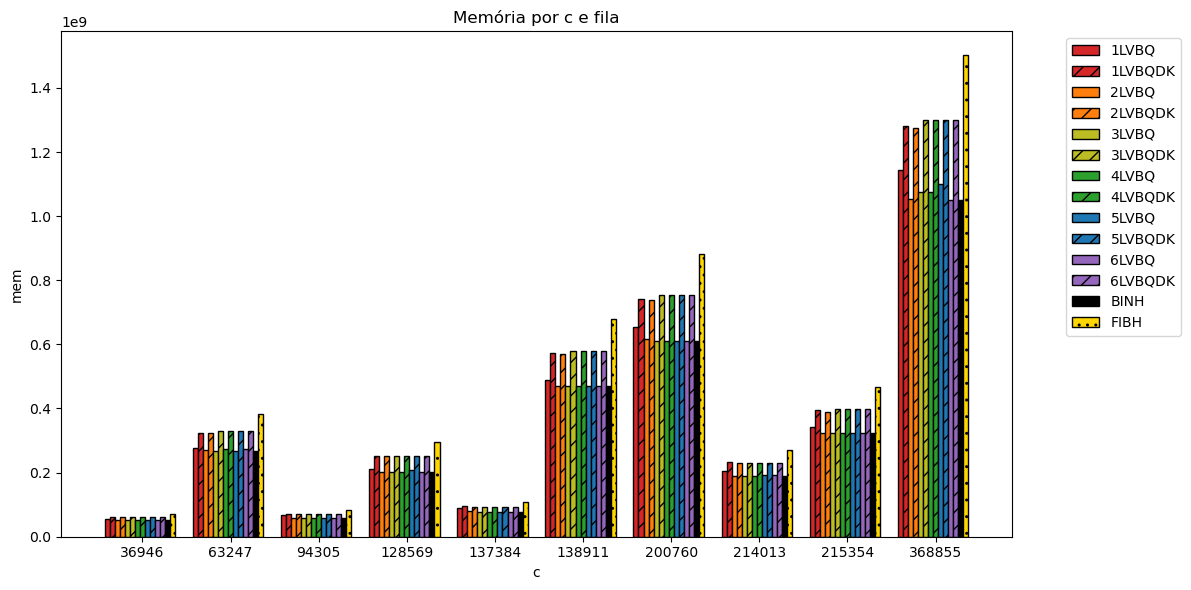

In [115]:
pivot = df_mem.pivot_table(
    index="c",
    columns="fila",
    values="mem",
    aggfunc="first"
)

c_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(c_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (cores exclusivas) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        # extrai número da fila (1–6)
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # padrão para DK
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, c_vals)
plt.xlabel("c")
plt.ylabel("mem")
plt.title("Memória por c e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [116]:
top3 = (
    df_mem
    .sort_values(['nome', 'mem'])
    .groupby('nome')
    .head(6)
)

top3['rank'] = top3.groupby('nome').cumcount() + 1

resultado = top3.pivot(
    index='nome',
    columns='rank',
    values=['fila', 'mem']
)

resultado.columns = [f'{col}{rank}' for col, rank in resultado.columns]

resultado = resultado.reset_index()
resultado

,nome,fila1,fila2,fila3,fila4,fila5,fila6,mem1,mem2,mem3,mem4,mem5,mem6
0,BAY,BINH,6LVBQ,5LVBQ,4LVBQ,3LVBQ,2LVBQ,58392576,58638336,58695680,58769408,58826752,58920960
1,CAL,BINH,5LVBQ,4LVBQ,3LVBQ,6LVBQ,2LVBQ,322453504,322568192,322715648,322781184,322801664,324628480
2,COL,BINH,6LVBQ,5LVBQ,4LVBQ,3LVBQ,2LVBQ,75952128,76279808,76308480,76333056,76361728,79200256
3,CTR,BINH,6LVBQ,5LVBQ,4LVBQ,3LVBQ,2LVBQ,2296659968,2296987648,2297139200,2297151488,2297507840,2307117056
4,E,BINH,5LVBQ,4LVBQ,3LVBQ,6LVBQ,2LVBQ,609112064,609271808,609435648,609517568,609636352,615620608
5,FLA,BINH,4LVBQ,3LVBQ,2LVBQ,5LVBQ,6LVBQ,187899904,188350464,188387328,189448192,192430080,192499712
6,LKS,BINH,5LVBQ,4LVBQ,3LVBQ,6LVBQ,2LVBQ,469184512,469377024,469565440,469700608,469864448,470548480
7,NE,BINH,5LVBQ,3LVBQ,2LVBQ,4LVBQ,6LVBQ,267821056,268173312,268689408,269303808,274112512,274235392
8,NW,BINH,6LVBQ,3LVBQ,4LVBQ,2LVBQ,5LVBQ,202010624,202227712,202264576,202428416,202604544,207020032
9,NY,BINH,6LVBQ,4LVBQ,5LVBQ,3LVBQ,2LVBQ,51466240,51732480,51769344,51879936,52011008,53256192


# Operações

# Tempo de execução e outras métricas

In [117]:
df_tcache.head()

,nome,n,m,c,fila,cpu_time,wall_time,l1,l2,llc,cycles,inst,dtlb,page_faults,rss,branch_inst,branch_miss
0,NY,264346,733846,36946,1LVBQ,79,79,3728319,2361577,149158,350157876,743297595,36114,1849,51456,107291011,956653
1,NY,264346,733846,36946,1LVBQ,79,79,3868715,2449122,146766,349889623,747508937,34424,1167,53416,108123627,1012986
2,NY,264346,733846,36946,1LVBQ,77,77,3703480,2371704,145376,344293462,742262493,32549,749,53456,107183515,950130
3,NY,264346,733846,36946,1LVBQ,76,77,3733814,2389058,143843,344583098,742262310,33104,517,54492,107183333,950120
4,NY,264346,733846,36946,1LVBQ,77,77,3749685,2410203,145645,346139418,742262537,32181,0,54492,107182938,949806


In [118]:
df_cpu = df_tcache[['nome', 'n', 'c', 'fila', 'cpu_time']]
df_cpu

,nome,n,c,fila,cpu_time
0,NY,264346,36946,1LVBQ,79
1,NY,264346,36946,1LVBQ,79
2,NY,264346,36946,1LVBQ,77
3,NY,264346,36946,1LVBQ,76
4,NY,264346,36946,1LVBQ,77
...,...,...,...,...,...
1675,USA,23947347,368855,FIBH,21265
1676,USA,23947347,368855,FIBH,21440
1677,USA,23947347,368855,FIBH,21324
1678,USA,23947347,368855,FIBH,21427


In [119]:
df_cpu = (
    df_cpu.groupby(['nome', 'fila'], as_index=False)
      .agg(
           cpu_mean=('cpu_time', 'mean'),
           cpu_std =('cpu_time', 'std'),
           cpu_var =('cpu_time', 'var'),
           n=('n', 'first'),
      )
)
df_cpu

,nome,fila,cpu_mean,cpu_std,cpu_var,n
0,BAY,1LVBQ,97.3,1.251666,1.566667,321270
1,BAY,1LVBQDK,74.1,1.100505,1.211111,321270
2,BAY,2LVBQ,103.2,0.421637,0.177778,321270
3,BAY,2LVBQDK,80.4,0.966092,0.933333,321270
4,BAY,3LVBQ,96.7,0.483046,0.233333,321270
...,...,...,...,...,...,...
163,W,5LVBQDK,2209.1,4.483302,20.100000,6262104
164,W,6LVBQ,2373.9,1.728840,2.988889,6262104
165,W,6LVBQDK,2229.8,4.022161,16.177778,6262104
166,W,BINH,3235.8,3.224903,10.400000,6262104


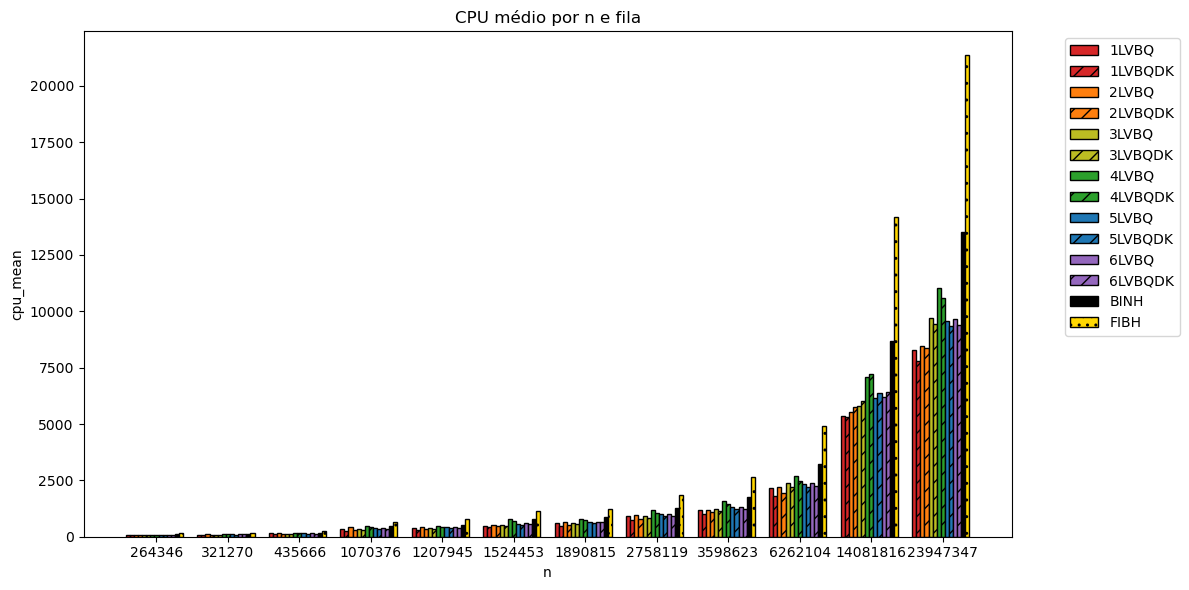

In [120]:
pivot = df_cpu.pivot_table(
    index="n",
    columns="fila",
    values="cpu_mean",
    aggfunc="first"
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("cpu_mean")
plt.title("CPU médio por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

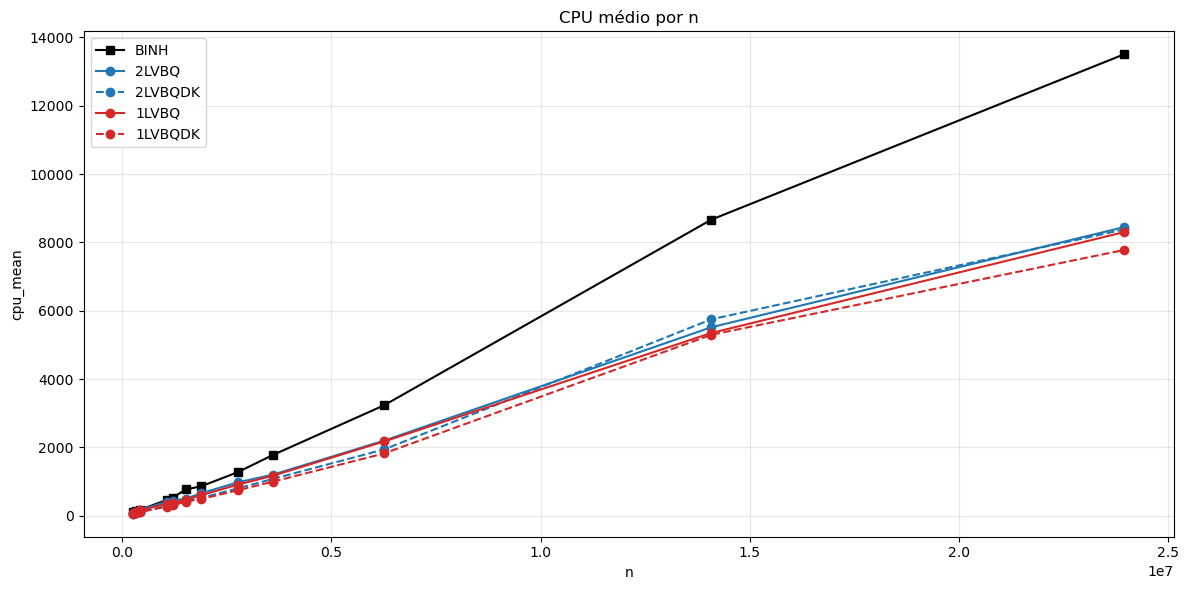

In [124]:
# 🎯 filas desejadas
filas_sel = ["BINH", "2LVBQ", "2LVBQDK", "1LVBQ", "1LVBQDK"]

df_sel = df_cpu[df_cpu["fila"].isin(filas_sel)].copy()

# ordenar por n (IMPORTANTÍSSIMO para linhas)
df_sel = df_sel.sort_values("n")

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== estilos =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    elif "LVBQDK" in fila:
        color = "tab:red" if fila.startswith("1") else "tab:blue"
        linestyle = "--"
        marker = "o"

    else:  # LVBQ
        color = "tab:red" if fila.startswith("1") else "tab:blue"
        linestyle = "-"
        marker = "o"

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("cpu_mean")
plt.title("CPU médio por n")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [121]:
df_wall = df_tcache[['nome', 'n', 'c', 'fila', 'wall_time']]
df_wall

,nome,n,c,fila,wall_time
0,NY,264346,36946,1LVBQ,79
1,NY,264346,36946,1LVBQ,79
2,NY,264346,36946,1LVBQ,77
3,NY,264346,36946,1LVBQ,77
4,NY,264346,36946,1LVBQ,77
...,...,...,...,...,...
1675,USA,23947347,368855,FIBH,21267
1676,USA,23947347,368855,FIBH,21443
1677,USA,23947347,368855,FIBH,21331
1678,USA,23947347,368855,FIBH,21431


In [122]:
df_wall = (
    df_wall.groupby(['nome', 'fila'], as_index=False)
      .agg(
           wall_mean=('wall_time', 'mean'),
           wall_std =('wall_time', 'std'),
           wall_var =('wall_time', 'var'),
           n=('n', 'first'),
      )
)
df_wall

,nome,fila,wall_mean,wall_std,wall_var,n
0,BAY,1LVBQ,97.3,1.251666,1.566667,321270
1,BAY,1LVBQDK,74.1,1.100505,1.211111,321270
2,BAY,2LVBQ,103.2,0.421637,0.177778,321270
3,BAY,2LVBQDK,80.4,0.966092,0.933333,321270
4,BAY,3LVBQ,96.7,0.483046,0.233333,321270
...,...,...,...,...,...,...
163,W,5LVBQDK,2209.5,4.403282,19.388889,6262104
164,W,6LVBQ,2374.2,1.549193,2.400000,6262104
165,W,6LVBQDK,2230.2,3.938415,15.511111,6262104
166,W,BINH,3236.1,3.107339,9.655556,6262104


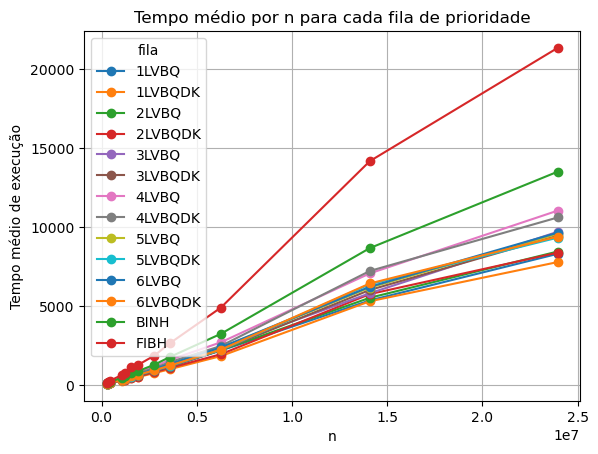

In [123]:
pivot = df_wall.groupby(['n','fila'])['wall_mean'].mean().unstack()

pivot.plot(marker='o')
plt.xlabel('n')
plt.ylabel('Tempo médio de execução')
plt.title('Tempo médio por n para cada fila de prioridade')
plt.grid(True)
plt.show()
